# ZQE for Poisson GLLVM — encoder & link function comparison

## Setup

ZQE vs a VAE baseline and R's `gllvm` (VA) on simulated Poisson data. The decoder is a
`PoissonGLM` with the ZQE statistic set at construction — `add_glm(PoissonGLM, ..., params={"T": torch.log1p})`.
Fitting uses **`ZQEAutoFitter`** (`gllvm.autofit`): an Adam warm-up followed by `n_heads`
independent SGD + Polyak "heads", combined into an orthogonally-aligned consensus. The
cross-head dispersion is a convergence diagnostic and `loading_se_` is a free frequentist
uncertainty on the loadings.

> **Note (encoder wiring).** Earlier versions of this notebook fit with `ZQEPoissonFitter`,
> which **hardcoded a Poisson-Newton MAP E-step and ignored the `enc` object** — so the
> `"gaussian_map"` arm only chose which encoder got *plotted*, not which one was used to fit.
> `ZQEAutoFitter` takes an `encoder_factory` and actually uses it, so the Gaussian MAP encoder
> is now exercised in the fit. (It works: the Gaussian encoder was never broken, just unwired.)

| Method | Procrustes ↓ (prior N=1000, q=1 run) |
|---|---|
| VAE (log1p encoder + log1p decoder) | 0.298 |
| ZQE — Gaussian MAP encoder, log1p decoder | **0.044** |
| ZQE — Poisson MAP encoder, log1p decoder | **0.043** |
| R `gllvm` VA | 0.045 |

**Key takeaways:**

1. **Encoder choice barely matters** once the decoder link is right — and crucially, the
   encoder's own transform need not match the decoder's `T(y)`: the score-function identity
   means encoder misspecification affects only efficiency, not bias on θ.

2. **ZQE ≈ R gllvm (VA)** without any explicit likelihood approximation, in a form that scales
   to large $N$, $p$, $q$ on GPU.

3. **The log1p `T(y)` is doing the heavy lifting.** The canonical `T=y` explodes at random
   decoder init (large synthetic Poisson rates); `log1p` bounds the centring term.

## Low-variance estimation

The parameters (loadings $W$) are the object of inference, so the fit prioritises statistical
accuracy: constant-LR SGD + Polyak–Ruppert averaging per head, then an aligned mean across heads.
The post-alignment cross-head spread (`loading_se_`) quantifies the residual optimisation
randomness — drive it below `tol` (more rounds), or let the LR escalate on repeated stalls.


In [ ]:
%load_ext autoreload
%autoreload 2

import os, random, copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.simulations import make_sparse, simulate
from gllvm.encoder import Encoder, MapEncoderGaussianLog1p, MapEncoderPoissonNewton
from gllvm.fitter import VAEFitter
from gllvm.autofit import ZQEAutoFitter
from gllvm.glms import PoissonGLM            # ZQE statistic set per-instance: PoissonGLM(linpar, T=torch.log1p)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)


## goood settings for us


NL  = 2      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 400     # number of responses
NS  = 20    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)

NL  = 5      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 400     # number of responses
NS  = 20    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)


NL  = 5      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 400     # number of responses
NS  = 100    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)


NL  = 2      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 20     # number of responses
NS  = 1000    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)


NL  = 2      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 20     # number of responses
NS  = 1000    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)

## Simulation


In [2]:
torch.manual_seed(142543)

NL  = 2      # number of latent dims
ACT = NL     # active latents per response (= NL → dense, all latents identified)
NR  = 20     # number of responses
NS  = 100    # number of observations
WZS = 1.5    # loading scale
RPL = NR   # None = dense loadings (each latent affects all responses)
             # set to NR//2 for row-sparse loadings (breaks dense decoders without L1)

g0m = make_sparse(n_latent=NL, poisson=NR, active_latent=ACT,
                  wz_scale=WZS, responses_per_latent=RPL).to(DEV)
y_all, z_all = simulate(g0m, n_samples=NS, device=DEV)

n_val  = int(0.15 * NS)
yt, yv = y_all[n_val:], y_all[:n_val]   # VAE uses train/val split
y_zqe  = y_all                           # ZQE uses all samples

print(f"g0m: p={g0m.p}  q={NL}  N={NS}")
print(f"y range: [{y_all.min().item():.0f}, {y_all.max().item():.0f}]")
print(f"true W shape: {g0m.wz.shape}")
W_nz = (g0m.wz.detach().cpu() != 0)
print(f"W non-zero per column: {W_nz.sum(0).tolist()}  (of {NR})")


# ── Procrustes helpers ────────────────────────────────────────────────────────
def _best_rotation(A, B):
    """Orthogonal Procrustes minimising ||A - B@R||, allowing reflections."""
    U, _, Vt = np.linalg.svd(A.T @ B)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(A - B @ R1) <= np.linalg.norm(A - B @ R2) else R2

def procr(g_true, g_est):
    a = g_true.wz.detach().cpu().numpy()
    b = g_est.wz.detach().cpu().numpy()
    R = _best_rotation(a, b)
    return float(np.linalg.norm(a - b @ R) / np.linalg.norm(a))

def _best_rotation_z(Z_true, Z_hat):
    U, _, Vt = np.linalg.svd(Z_true.T @ Z_hat)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(Z_true - Z_hat @ R1) <= np.linalg.norm(Z_true - Z_hat @ R2) else R2


g0m: p=20  q=2  N=100
y range: [0, 7197]
true W shape: torch.Size([20, 2])
W non-zero per column: [20, 20]  (of 20)


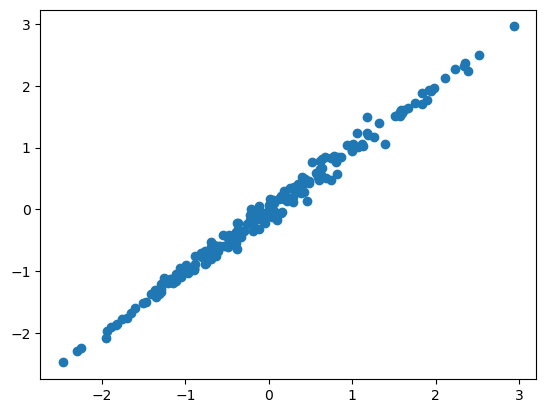

In [3]:
enc = MapEncoderPoissonNewton(g0m, lam=0.0, max_iter=100, tol=1e-8)
zhat = enc(y_zqe)
# TODO: WEIRD! TEST THAT for very large poisson, it is not perfect estimated at oracle!
plt.scatter(z_all.flatten().cpu().numpy(), zhat.flatten().cpu().numpy())

In [4]:
from gllvm.glm_fit import initial_gaussian_fit, poisson_newton_batch

B_true = g0m.wz.detach().cpu()
offset = g0m.bias.detach().cpu()

X = B_true
Y = y_all.T.cpu()
offset = offset.unsqueeze(1).expand_as(Y)


B0 = initial_gaussian_fit(X, Y, offset=offset)
B_hat, info = poisson_newton_batch(X, Y, B0, lam=0, offset=offset, verbose=True)
z_hat = B_hat.T

Newton it=  1 rel_change=2.792e-01 halvings=6
Newton it=  2 rel_change=4.130e-01 halvings=3
Newton it=  3 rel_change=3.394e-01 halvings=1
Newton it=  4 rel_change=1.276e-01 halvings=0
Newton it=  5 rel_change=1.379e-02 halvings=0
Newton it=  6 rel_change=4.935e-04 halvings=0
Newton it=  7 rel_change=8.558e-07 halvings=0


In [5]:
import numpy as np
from sklearn.linear_model import PoissonRegressor

X_num =X.cpu().numpy()
Y_num = Y.cpu().numpy()
offset_num = offset.cpu().numpy()

Y_trans = Y_num / np.exp(offset_num)

model = PoissonRegressor(alpha=0, fit_intercept=False, solver="newton-cholesky", tol=1e-8)
model.fit(X_num, Y_trans[:, 15], sample_weight=np.exp(offset_num[:, 15]))

/home/willwhite/miniconda3/envs/torch/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/home/willwhite/miniconda3/envs/torch/lib/python3.10/site-packages/sklearn/linear_model/_glm/_newton_solver.py:289: ConvergenceWarning: Line search of Newton solver NewtonCholeskySolver at iteration #6 did no converge after 21 line search refinement iterations. It will now resort to lbfgs instead.
  warnings.warn(


,alpha,0
,fit_intercept,False
,solver,'newton-cholesky'
,max_iter,100
,tol,1e-08
,warm_start,False
,verbose,0


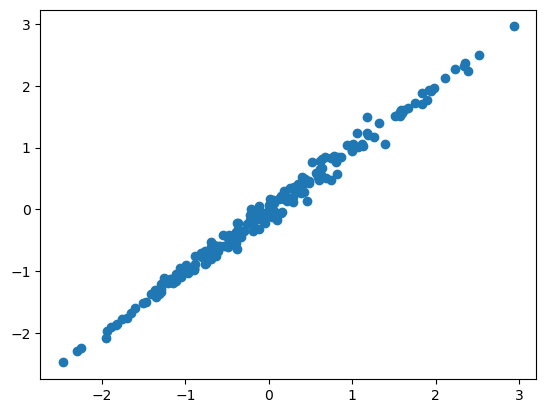

In [6]:
plt.scatter(z_all.flatten().cpu().numpy(), z_hat.flatten().cpu().numpy())

## Setup


In [ ]:
VAE_HIDDEN = max(64, min(256, int(NR ** 0.5) * 4))


class Log1pEncoder(Encoder):
    """VAE encoder with log1p input normalisation."""
    def forward(self, y):
        return super().forward(torch.log1p(y.float()))


def fresh_decoder(T=torch.log1p):
    """Fresh dense GLLVM decoder — no mask, no knowledge of the true sparse structure.

    The ZQE statistic T(y) is configured on the family itself (default log1p);
    sampling / log_prob are unchanged by T.
    """
    from gllvm.gllvm_module import GLLVM
    g = GLLVM(latent_dim=NL, output_dim=NR, bias=True).to(DEV)
    g.add_glm(PoissonGLM, idx=list(range(NR)), params={"T": T}, name="P")
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g


# Encoder factories: g -> parameter-free encoder bound to decoder g.
# NOTE: the encoder's own transform (log1p Gaussian proxy) is independent of the
# decoder's T(y) — they need not match (score-function identity → no bias on theta).
ENC_FACTORIES = {
    "gaussian_map": lambda g: MapEncoderGaussianLog1p(g),
    "poisson_map":  lambda g: MapEncoderPoissonNewton(g, lam=1.0, max_iter=30),
}


In [ ]:

# ── VAE baseline ──────────────────────────────────────────────────────────────
g_vae   = fresh_decoder().to(DEV)          # PoissonGLM decoder, T(y)=log1p
enc_vae = Log1pEncoder(input_dim=NR, latent_dim=NL, hidden=VAE_HIDDEN).to(DEV)

WARMUP_EP = max(300, NR // 4)
fv = VAEFitter(g_vae, enc_vae, lr=1e-2, device=DEV)
fv.fit(yt, epochs=WARMUP_EP, batch_size=256, verbose=False)

for lr_stage, patience_stage in [(3e-3, 80), (1e-3, 100), (3e-4, 120), (1e-4, 150), (3e-5, 200)]:
    fitter = VAEFitter(g_vae, enc_vae, lr=lr_stage, device=DEV)
    best_ve = float("-inf"); no_imp = 0
    best_wz_v = best_b_v = best_enc_sd = None
    for ep in range(2000):
        fitter.fit(yt, epochs=1, batch_size=256, verbose=False)
        with torch.no_grad():
            _, ve = enc_vae.loss(yv.to(DEV), g_vae)
        if ve > best_ve + 0.05:
            best_ve, no_imp = ve, 0
            best_wz_v  = g_vae.wz.detach().clone()
            best_b_v   = g_vae.bias.detach().clone()
            best_enc_sd = copy.deepcopy(enc_vae.state_dict())
        else:
            no_imp += 1
            if no_imp >= patience_stage:
                break
    g_vae.wz.data.copy_(best_wz_v); g_vae.bias.data.copy_(best_b_v)
    enc_vae.load_state_dict(best_enc_sd)

err_vae = procr(g0m, g_vae)
print(f"VAE Procrustes = {err_vae:.4f}")


## ZQE Training


In [ ]:
ARMS = [
    # (label,                  colour,       encoder key in ENC_FACTORIES)
    ("Gaussian MAP (log1p)",   "tab:blue",   "gaussian_map"),
    # ("Poisson MAP (log1p)",    "tab:orange", "poisson_map"),   # uncomment to confirm "encoder barely matters"
]

results = {}   # label -> (fitter, colour, enc_factory)

for label, colour, enc_key in ARMS:
    try:
        g           = fresh_decoder()                  # PoissonGLM, T(y)=log1p
        enc_factory = ENC_FACTORIES[enc_key]           # the encoder is now ACTUALLY used in the fit
        ft = ZQEAutoFitter(
            g, encoder_factory=enc_factory, device=DEV, seed=SEED,
            n_heads=4, steps_per_round=150, max_rounds=5, tol=0.02,
            refine_lr=0.3, verbose=True,
        )
        print(f"\n[{label}]  Proc0={procr(g0m, g):.4f}")
        ft.fit(y_zqe)
        print(f"[{label}]  Procrustes = {procr(g0m, ft.model):.4f}   "
              f"cross-head dispersion = {ft.dispersion_:.4f}   "
              f"loadings SE(mean) = {ft.loading_se_.mean():.4f}   "
              f"converged = {ft.converged_}")
        results[label] = (ft, colour, enc_factory)
    except Exception as _e:
        print(f"[{label}] FAILED: {_e}")
        import traceback; traceback.print_exc()


[skip] no data to plot for Deviance


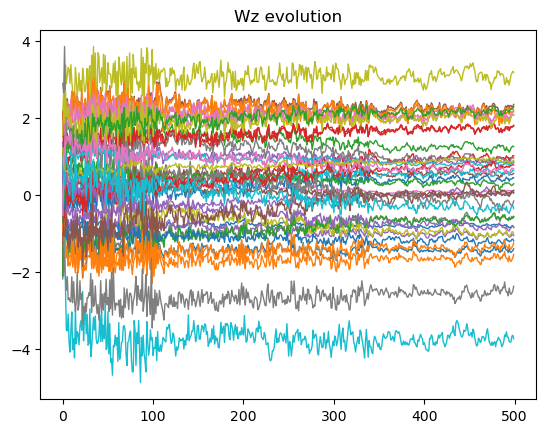

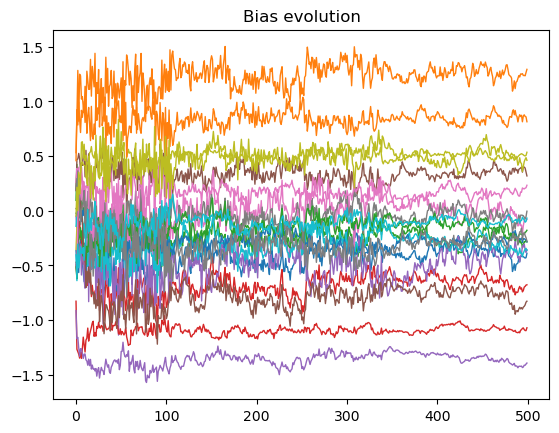

[skip] no data to plot for Latent evolution (fixed y-samples)


In [10]:
ft.history.plot()

## Results


In [ ]:
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
fig.suptitle(f"ZQEAutoFitter training  (N={NS}, NL={NL}, NR={NR})")

for label, (ft, col, _ef) in results.items():
    h = ft.history
    ax0.plot(h["warmup_loss"], color=col, lw=1.2, label=label)
    ax1.semilogy(h["warmup_gnorm"], color=col, lw=1.2, label=label)
    rounds = range(1, len(h["round_dispersion"]) + 1)
    ax2.semilogy(rounds, h["round_dispersion"], "o-", color=col, lw=1.4, label=label)

ax0.axhline(0, color="gray", ls=":", lw=0.8)
ax0.set_ylabel("ZQE loss");              ax0.legend(fontsize=8); ax0.set_xlabel("Warm-up epoch (Adam)")
ax1.set_ylabel("Grad norm (log)");       ax1.legend(fontsize=8); ax1.set_xlabel("Warm-up epoch (Adam)")
ax2.set_ylabel("Cross-head dispersion"); ax2.legend(fontsize=8); ax2.set_xlabel("Refine round (SGD+Polyak heads)")
ax2.axhline(list(results.values())[0][0].tol, color="gray", ls=":", lw=0.8)   # convergence tol
plt.tight_layout(); plt.show()

# ── Final Procrustes table (with the free cross-head uncertainty) ─────────────
print(f"\n{'Method':<40} {'Procrustes':>12} {'Dispersion':>12}")
print("─" * 66)
print(f"{'VAE':<40} {err_vae:>12.4f} {'—':>12}")
for label, (ft, col, _ef) in results.items():
    print(f"{label:<40} {procr(g0m, ft.model):>12.4f} {ft.dispersion_:>12.4f}")


In [ ]:
# ── Z prediction scatter ──────────────────────────────────────────────────────
z_true_np = z_all.cpu().numpy()
n_arms = len(results)

fig_z, axes_z = plt.subplots(n_arms, NL, figsize=(4 * NL, 3.5 * n_arms), squeeze=False)
fig_z.suptitle(f"Z prediction vs true  (N={NS}, NL={NL}, NR={NR})", fontsize=12)

for row, (label, (ft, col, enc_factory)) in enumerate(results.items()):
    enc = enc_factory(ft.model)          # encoder bound to the consensus decoder
    with torch.no_grad():
        z_hat, _, _ = enc.sample(y_zqe.to(DEV))
    z_hat_np  = z_hat.cpu().numpy()
    R         = _best_rotation_z(z_true_np, z_hat_np)
    z_hat_rot = z_hat_np @ R

    corr = [np.corrcoef(z_true_np[:, k], z_hat_rot[:, k])[0, 1] for k in range(NL)]

    for col_idx in range(NL):
        ax = axes_z[row, col_idx]
        ax.scatter(z_true_np[:, col_idx], z_hat_rot[:, col_idx],
                   s=6, alpha=0.4, color=col, edgecolors="none")
        lim = max(np.abs(z_true_np[:, col_idx]).max(),
                  np.abs(z_hat_rot[:, col_idx]).max()) * 1.15
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        ax.set_title(f"{label}\nz[{col_idx}]  r={corr[col_idx]:.3f}", fontsize=8)
        if row == n_arms - 1: ax.set_xlabel("True $z$", fontsize=8)
        if col_idx == 0:      ax.set_ylabel(r"$\hat{z}$ (rotated)", fontsize=8)

plt.tight_layout(); plt.show()


## R gllvm Benchmark (VA)


In [13]:
import subprocess, os, textwrap
import pandas as pd

RSCRIPT    = "/mnt/c/Program Files/R/R-4.5.1/bin/Rscript.exe"
WIN_TMPDIR = "/mnt/c/Users/willwhite/AppData/Local/Temp/r_gllvm_bench"
os.makedirs(WIN_TMPDIR, exist_ok=True)

def wsl2r(path):
    """Convert /mnt/c/... WSL path to C:/... forward-slash path for R."""
    return path.replace("/mnt/c/", "C:/")

def run_r_gllvm(Y_np, W_true_np, n_latent, method="VA", family="poisson", seed=42):
    y_path = os.path.join(WIN_TMPDIR, "Y.csv")
    w_path = os.path.join(WIN_TMPDIR, f"W_hat_{method}.csv")
    r_path = os.path.join(WIN_TMPDIR, f"run_{method}.R")

    if os.path.exists(w_path):
        os.remove(w_path)

    pd.DataFrame(Y_np).to_csv(y_path, index=False, header=False)

    r_code = textwrap.dedent(f"""
        set.seed({seed})
        Y <- as.matrix(read.csv("{wsl2r(y_path)}", header=FALSE))
        suppressPackageStartupMessages(library(gllvm))
        fit <- gllvm(Y, num.lv={n_latent}, family="{family}",
                     method="{method}",
                     control=list(TMB=TRUE, maxit=2000, trace=FALSE),
                     control.start=list(starting.val="res"))
        W_full <- sweep(fit$params$theta, 2, fit$params$sigma.lv, "*")
        write.csv(W_full, "{wsl2r(w_path)}", row.names=FALSE)
        cat("converged\\n")
    """)

    with open(r_path, "w") as f:
        f.write(r_code)

    result = subprocess.run(
        [RSCRIPT, "--vanilla", wsl2r(r_path)],
        capture_output=True, text=True, timeout=600
    )
    if result.returncode != 0 or not os.path.exists(w_path):
        print("R stderr:", result.stderr[-1500:])
        return None

    W_hat = pd.read_csv(w_path).values
    U, _, Vt = np.linalg.svd(W_true_np.T @ W_hat)
    R = (U @ Vt).T
    err = float(np.linalg.norm(W_true_np - W_hat @ R) / np.linalg.norm(W_true_np))
    return err, W_hat

# ── run VA only ───────────────────────────────────────────────────────────────
Y_int    = y_all.cpu().numpy().astype(int)
W_true_r = g0m.wz.detach().cpu().numpy()

r_results = {}
print("Fitting R gllvm (VA) ...")
out = run_r_gllvm(Y_int, W_true_r, n_latent=NL, method="VA")
if out is not None:
    err, W_hat = out
    r_results["R gllvm (VA)"] = (err, W_hat)
    print(f"  R gllvm VA  Procrustes = {err:.4f}")
else:
    print("  R gllvm VA failed")
    r_results["R gllvm (VA)"] = (float("nan"), None)


Fitting R gllvm (VA) ...
  R gllvm VA  Procrustes = 0.1396
  R gllvm VA  Procrustes = 0.1396


## Summary


In [ ]:
W_true_np = g0m.wz.detach().cpu().numpy()

def _aligned_w(W_t, W_h):
    return W_h @ _best_rotation(W_t, W_h)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Method':<40}  {'Procrustes':>12}")
print("-" * 54)
print(f"{'VAE baseline':<40}  {err_vae:>12.4f}")
for label, (ft, col, _ef) in results.items():
    print(f"{label:<40}  {procr(g0m, ft.model):>12.4f}")
for rname, (rerr, _) in r_results.items():
    print(f"{rname:<40}  {rerr:>12.4f}")

# ── Rotated loadings scatter ───────────────────────────────────────────────────
plot_methods = [("VAE baseline", "tab:gray", g_vae.wz.detach().cpu().numpy())]
for label, (ft, col, _ef) in results.items():
    plot_methods.append((label, col, ft.model.wz.detach().cpu().numpy()))
for rname, (rerr, W_hat) in r_results.items():
    if W_hat is not None:
        plot_methods.append((rname, "tab:green", W_hat))

ncols = len(plot_methods)
fig_w, axes_w = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4), squeeze=False)
fig_w.suptitle("Estimated vs true loadings $W_z$ (after Procrustes rotation)", fontsize=11)

for ax, (label, col, W_hat) in zip(axes_w[0], plot_methods):
    W_rot = _aligned_w(W_true_np, W_hat)
    ax.scatter(W_true_np.ravel(), W_rot.ravel(),
               s=8, alpha=0.4, color=col, edgecolors="none")
    lim = max(np.abs(W_true_np).max(), np.abs(W_rot).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.9, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=8)
    ax.set_xlabel("True $w_{ij}$", fontsize=8)
axes_w[0, 0].set_ylabel(r"Est. $\hat{w}_{ij}$", fontsize=8)

plt.tight_layout(); plt.show()
